# Paso 05 -- Comparar el agente PPO contra la politica base

Corre el agente entrenado (`modelo_rl/output/modelo_final/modelo_ppo.zip`,
`01_enfoque_y_entrenamiento_final.ipynb`) y la politica base (`asignar_flota`)
sobre las MISMAS semillas de evaluacion (`agente.evaluacion.semillas` en el
config -- distintas de `semilla_entrenamiento`, para no evaluar sobre
demandas ya vistas), en la misma instancia de entrenamiento (escalon chico).
Misma semilla -> misma demanda para las dos politicas (ver
`modelo_rl/src/entrenamiento.py`), asi la comparacion es justa.

**Como se agregan los resultados:** igual que el escalon 3 (semana) -- cada
semilla de evaluacion es su propio episodio independiente;
`metricas.combinar_corridas` junta los N episodios de cada politica en un
solo objeto y `metricas.reporte_completo` da las mismas tablas de siempre,
ahora una por politica, listas para comparar lado a lado. Cero funciones de
metricas nuevas.

**Objetivo de esta primera version:** mostrar si el agente iguala o supera
a la politica base -- no se exige que gane.

**Detalle de una semilla concreta (mas abajo):** ademas del agregado de las
5 semillas, se genera para la semilla 1001 el MISMO paquete completo de
metricas/graficas que produce un notebook de escalon (perfil de espera,
ocupacion de flota en el tiempo, heatmap de cumplimiento por par, desglose
de recompensa, backlog por par) para las DOS politicas sobre esa misma
semilla, lado a lado -- para ver el comportamiento concreto, no solo el
promedio.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt

BASE_DIR = Path.cwd().parent
SIMULADOR_DIR = (BASE_DIR / "../simulador").resolve()
POLITICA_BASE_DIR = (BASE_DIR / "../politica_base").resolve()
MODELO_RL_DIR = (BASE_DIR / "../modelo_rl").resolve()
BB_DIR = (BASE_DIR / "../bergen-boats").resolve()
DEMAND_DIR = (BASE_DIR / "../demand").resolve()
sys.path.insert(0, str(DEMAND_DIR / "src"))
sys.path.insert(0, str(SIMULADOR_DIR / "src"))
sys.path.insert(0, str(POLITICA_BASE_DIR / "src"))
sys.path.insert(0, str(MODELO_RL_DIR / "src"))

import masas as demand_masas
import llegadas as demand_llegadas
from entrenamiento import EntornoDemandaAleatoria
from politica_base import asignar_flota
import metricas as met
import visualizacion as viz
from stable_baselines3 import PPO

cfg_sim = yaml.safe_load(open(SIMULADOR_DIR / "config" / "instance.yaml", encoding="utf-8"))
cfg_bb = yaml.safe_load(open(BB_DIR / "config" / "instance.yaml", encoding="utf-8"))
cfg_demand = demand_masas.cargar_config(DEMAND_DIR / "config" / "instance.yaml")

resumen_masas = pd.read_csv(DEMAND_DIR / "output" / "masas_por_nodo.csv", index_col="id")
intensidad_od = pd.read_csv(DEMAND_DIR / "output" / "matriz_intensidad_od.csv")
poblacion_total_zonas = resumen_masas["poblacion_total"].sum()
conexiones_fuertes = cfg_bb["garantia"]["conexiones_fuertes"]

nodos = [n["id"] for n in cfg_bb["nodos_demanda"]]
matriz_tiempos = pd.read_csv(BB_DIR / "02_ruteo_navegable" / "output" / "matriz_tiempos_min.csv", index_col=0)

cfg_agente = cfg_sim["agente"]
cfg_entren = cfg_agente["entrenamiento"]
cfg_escalon = cfg_sim["escalones"][cfg_entren["escalon_base"]]
hora_ini_min, hora_fin_min = cfg_escalon["horas"][0] * 60, cfg_escalon["horas"][1] * 60
semillas_eval = cfg_agente["evaluacion"]["semillas"]

# Mismos overrides de recompensa que uso el entrenamiento final
# (01_enfoque_y_entrenamiento_final.ipynb) -- ver config/instance.yaml,
# agente.entrenamiento.recompensa_overrides (combo ganador de
# 02_secuencia_experimentos_reward.ipynb). Se aplican a AMBAS politicas aca
# (agente y base) para que el reward reportado sea comparable 1:1 -- si el
# agente usara una formula de recompensa distinta a la base, la comparacion
# de reward total no significaria nada.
cfg_recompensa_rl = dict(cfg_sim["recompensa"])
cfg_recompensa_rl.update(cfg_entren.get("recompensa_overrides", {}))

RL_DIR = MODELO_RL_DIR / "output" / "modelo_final"
OUT_DIR = BASE_DIR / "output"
OUT_DIR.mkdir(parents=True, exist_ok=True)

model = PPO.load(str(RL_DIR / "modelo_ppo"))
print("Modelo cargado de", RL_DIR / "modelo_ppo.zip")
print(f"Instancia de evaluacion: {cfg_entren['escalon_base']}, semillas: {semillas_eval}")
print(f"Overrides de recompensa (solo RL): {cfg_entren.get('recompensa_overrides', {})}")


def construir_entorno_eval():
    return EntornoDemandaAleatoria(
        generar_llegadas_dia_fn=demand_llegadas.generar_llegadas_dia,
        cfg_demand=cfg_demand, intensidad_od=intensidad_od, conexiones_fuertes=conexiones_fuertes,
        poblacion_total_zonas=poblacion_total_zonas, horas=cfg_escalon["horas"],
        porcentaje_poblacion_dia=cfg_escalon["porcentaje_poblacion_dia"],
        matriz_tiempos=matriz_tiempos, nodos=nodos, num_barcos=cfg_escalon["num_barcos"],
        capacidad_barco=cfg_bb["flota"]["capacidad_pasajeros"], nodo_inicial=cfg_bb["flota"]["nodo_inicial"],
        paso_tiempo_min=cfg_sim["paso_tiempo_min"], hora_inicio_min=hora_ini_min, hora_fin_min=hora_fin_min,
        cfg_recompensa=cfg_recompensa_rl, unidad_demanda=cfg_sim["unidad_demanda"],
    )


# B.6: consistencia train/eval -- prueba estructural, no solo de nombre. Si el
# entrenamiento y esta evaluacion usaran escalones distintos (p.ej. entrenar en
# escalon_1, evaluar en escalon_2), la dimension del vector aplanado casi
# seguro seria distinta (depende de num_barcos) -- esto lo confirma en tiempo
# de ejecucion, no solo comparando la clave de config.
_dim_modelo = model.observation_space.shape
_dim_eval = construir_entorno_eval().observation_space.shape
assert _dim_modelo == _dim_eval, (
    f"Desajuste train/eval: el modelo espera observaciones de forma {_dim_modelo}, "
    f"pero {cfg_entren['escalon_base']} en esta evaluacion da {_dim_eval} -- entrenar y "
    f"evaluar deben usar el mismo escalon."
)
print(f"OK: train y eval usan el mismo escalon ({cfg_entren['escalon_base']}), "
      f"vector aplanado de forma {_dim_eval} en ambos.")

# VecNormalize (ver modelo_rl/README.md): si el entrenamiento final entreno con
# esto activo, hay que evaluar con las MISMAS estadisticas (congeladas, no se
# siguen actualizando) -- si no, el agente veria observaciones en una escala
# distinta a la que aprendio. `usar_vecnormalize_eval` se decide por la
# EXISTENCIA del archivo guardado, no leyendo el config (asi sigue
# funcionando si se evalua un modelo viejo entrenado sin esto).
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize

VECNORMALIZE_PATH = RL_DIR / "vecnormalize.pkl"
usar_vecnormalize_eval = VECNORMALIZE_PATH.exists()
print(f"VecNormalize en evaluacion: {usar_vecnormalize_eval} "
      f"({'encontrado' if usar_vecnormalize_eval else 'no encontrado'} {VECNORMALIZE_PATH.name})")


Modelo cargado de C:\Users\hfons\Andes\OneDrive - Universidad de los Andes\NHH\NHH-Schedule-Free-Autonomous-Boats-in-Bergen\modelo_rl\output\modelo_final\modelo_ppo.zip
Instancia de evaluacion: escalon_1, semillas: [1001, 1002, 1003, 1004, 1005]
Overrides de recompensa (solo RL): {'peso_movimiento': 0.003, 'penalizacion_maxima_persona': 1000000.0, 'premio_por_persona_entregada': 0.0}
OK: train y eval usan el mismo escalon (escalon_1), vector aplanado de forma (46,) en ambos.
VecNormalize en evaluacion: True (encontrado vecnormalize.pkl)


## Correr las dos politicas sobre las mismas semillas de evaluacion

In [2]:
def correr_agente(semilla):
    if not usar_vecnormalize_eval:
        env = construir_entorno_eval()
        obs, info = env.reset(seed=semilla)
        reward_total = 0.0
        while True:
            accion, _ = model.predict(obs, deterministic=True)
            obs, r, terminated, truncated, info = env.step(accion)
            reward_total += r
            if truncated or terminated:
                break
        return env, reward_total

    # Con VecNormalize: se steppea el entorno CRUDO directamente (NO a traves de
    # `venv.step()`) y solo se usan las estadisticas de VecNormalize para normalizar
    # la observacion antes de `predict()`. Se intento primero step-ear a traves del
    # DummyVecEnv (mas "de manual" de SB3) pero eso tiene un efecto secundario real:
    # `DummyVecEnv.step_wait()` AUTO-RESETEA el entorno interno en el mismo `step()`
    # en que `done=True` (comportamiento estandar de VecEnv, para no perder un paso
    # al encadenar episodios) -- eso borraba `atendidas_historico`/`log_eventos`
    # ANTES de poder leerlos, y `verificar_conservacion` daba todo en 0. Con el
    # entorno crudo (mismo patron ya usado y verificado en el diagnostico, ver
    # bitacora) el `reset()` lo controlamos nosotros, una sola vez, al principio.
    venv_stats = VecNormalize.load(str(VECNORMALIZE_PATH), DummyVecEnv([construir_entorno_eval]))
    venv_stats.training = False
    venv_stats.norm_reward = False  # comparar sobre recompensa CRUDA, igual que la politica base

    env = construir_entorno_eval()
    obs, info = env.reset(seed=semilla)
    reward_total = 0.0
    while True:
        obs_norm = venv_stats.normalize_obs(obs)
        accion, _ = model.predict(obs_norm, deterministic=True)
        obs, r, terminated, truncated, info = env.step(accion)
        reward_total += r
        if truncated or terminated:
            break
    return env, reward_total


def correr_base(semilla):
    env = construir_entorno_eval()
    obs, info = env.reset(seed=semilla)
    reward_total = 0.0
    while True:
        estado = info["_estado_obj"]
        libres = [b for b in estado.barcos if b.libre]
        decisiones = asignar_flota(libres, estado, matriz_tiempos, env.capacidad_barco, cfg_recompensa_rl)
        accion = np.array([
            env.codificar_accion_barco(decisiones[b.id]) if b.libre else 0
            for b in estado.barcos
        ])
        obs, r, terminated, truncated, info = env.step(accion)
        reward_total += r
        if truncated or terminated:
            break
    return env, reward_total


envs_agente, envs_base = [], []
filas_reward = []
for semilla in semillas_eval:
    env_a, r_a = correr_agente(semilla)
    env_b, r_b = correr_base(semilla)
    envs_agente.append(env_a)
    envs_base.append(env_b)
    filas_reward.append({"semilla": semilla, "reward_agente": r_a, "reward_base": r_b, "diferencia": r_a - r_b})
    print(f"semilla {semilla}: agente={r_a:8.2f}  base={r_b:8.2f}  diferencia={r_a - r_b:+8.2f}")

df_reward = pd.DataFrame(filas_reward)
df_reward.to_csv(OUT_DIR / "reward_por_semilla.csv", index=False)
print(f"\nPromedio: agente={df_reward['reward_agente'].mean():.2f}  base={df_reward['reward_base'].mean():.2f}")


semilla 1001: agente= -215.96  base= -132.82  diferencia=  -83.14
semilla 1002: agente= -640.06  base= -617.09  diferencia=  -22.97
semilla 1003: agente= -787.74  base= -318.76  diferencia= -468.98


semilla 1004: agente=-1699.31  base=-4091.05  diferencia=+2391.74
semilla 1005: agente= -411.07  base=  -99.33  diferencia= -311.74

Promedio: agente=-750.83  base=-1051.81


## Combinar las 5 corridas de cada politica y sacar las metricas de siempre

Mismo mecanismo que el escalon 3 (`metricas.combinar_corridas` +
`metricas.reporte_completo`) -- aca cada "dia" es una semilla de
evaluacion distinta, en vez de un dia de la semana.

In [3]:
corrida_agente = met.combinar_corridas(envs_agente)
corrida_base = met.combinar_corridas(envs_base)

reporte_agente = met.reporte_completo(corrida_agente)
reporte_base = met.reporte_completo(corrida_base)

print("Conservacion agente:", reporte_agente["conservacion"]["cuadra"])
print("Conservacion base:  ", reporte_base["conservacion"]["cuadra"])


Conservacion agente: True
Conservacion base:   True


## Tabla comparativa (globales)

In [4]:
claves_comparar = [
    "unidades_generadas", "unidades_atendidas", "unidades_sin_atender_al_final",
    "pct_atendidas", "espera_media_min", "sistema_medio_min", "sistema_maximo_min",
]
tabla_comparativa = pd.DataFrame({
    "metrica": claves_comparar,
    "agente_ppo": [reporte_agente["globales"][k] for k in claves_comparar],
    "politica_base": [reporte_base["globales"][k] for k in claves_comparar],
})
tabla_comparativa["diferencia"] = tabla_comparativa["agente_ppo"] - tabla_comparativa["politica_base"]

# Recompensa total y movimientos/ocupacion de flota, tambien comparados
tabla_comparativa = pd.concat([tabla_comparativa, pd.DataFrame([
    {"metrica": "reward_total", "agente_ppo": df_reward["reward_agente"].sum(),
     "politica_base": df_reward["reward_base"].sum(),
     "diferencia": df_reward["reward_agente"].sum() - df_reward["reward_base"].sum()},
    {"metrica": "movimientos_totales", "agente_ppo": reporte_agente["por_barco"]["movimientos"].sum(),
     "politica_base": reporte_base["por_barco"]["movimientos"].sum(),
     "diferencia": reporte_agente["por_barco"]["movimientos"].sum() - reporte_base["por_barco"]["movimientos"].sum()},
    {"metrica": "ocupacion_media", "agente_ppo": reporte_agente["por_barco"]["ocupacion_media"].mean(),
     "politica_base": reporte_base["por_barco"]["ocupacion_media"].mean(),
     "diferencia": reporte_agente["por_barco"]["ocupacion_media"].mean() - reporte_base["por_barco"]["ocupacion_media"].mean()},
])], ignore_index=True)

tabla_comparativa.to_csv(OUT_DIR / "tabla_comparativa.csv", index=False)
display(tabla_comparativa.round(2))


,metrica,agente_ppo,politica_base,diferencia
0,unidades_generadas,850.00,850.00,0.00
1,unidades_atendidas,746.00,748.00,-2.00
2,unidades_sin_atender_al_final,104.00,102.00,2.00
3,pct_atendidas,87.76,88.00,-0.24
4,espera_media_min,16.34,16.42,-0.07
5,sistema_medio_min,26.10,26.05,0.05
6,sistema_maximo_min,66.77,69.74,-2.97
7,reward_total,-3754.14,-5259.04,1504.90
8,movimientos_totales,185.00,155.00,30.00
9,ocupacion_media,3.49,3.50,-0.00


## Percentiles de espera/viaje/sistema (agregado, 5 semillas -- la base de una garantía de tiempo)

Mismo motivo que en cada escalón (`politica_base/README.md`): el simulador no pierde a nadie, así que los percentiles sobre las unidades atendidas son datos reales y sin censurar. Esto -- no solo el promedio -- es lo que permite proponer una garantía de servicio con sustento (p.ej. "95% de la gente esperó menos de X minutos").

In [5]:
percentiles_agente_agg = reporte_agente["por_usuario"]
percentiles_base_agg = reporte_base["por_usuario"]

filas_percentiles_agg = []
for metrica in ["espera_min", "viaje_min", "sistema_min"]:
    for pct in ["p50", "p90", "p95", "max"]:
        filas_percentiles_agg.append({
            "metrica": metrica, "percentil": pct,
            "agente_ppo": percentiles_agente_agg[metrica][pct],
            "politica_base": percentiles_base_agg[metrica][pct],
        })
tabla_percentiles_agregado = pd.DataFrame(filas_percentiles_agg)
tabla_percentiles_agregado["diferencia"] = tabla_percentiles_agregado["agente_ppo"] - tabla_percentiles_agregado["politica_base"]
tabla_percentiles_agregado.to_csv(OUT_DIR / "percentiles_agregado.csv", index=False)
display(tabla_percentiles_agregado.round(2))


,metrica,percentil,agente_ppo,politica_base,diferencia
0,espera_min,p50,14.05,13.93,0.12
1,espera_min,p90,31.92,37.19,-5.27
2,espera_min,p95,34.97,46.06,-11.09
3,espera_min,max,54.77,59.74,-4.97
4,viaje_min,p50,10.00,10.00,0.00
5,viaje_min,p90,12.00,12.00,0.00
6,viaje_min,p95,12.00,12.00,0.00
7,viaje_min,max,12.00,12.00,0.00
8,sistema_min,p50,23.52,22.98,0.54
9,sistema_min,p90,40.70,37.80,2.90


## Comparacion por par origen-destino

In [6]:
par_agente = reporte_agente["por_par"][["par", "pct_atendidas", "espera_media_min", "sistema_medio_min"]]
par_base = reporte_base["por_par"][["par", "pct_atendidas", "espera_media_min", "sistema_medio_min"]]
por_par_comparado = par_agente.merge(par_base, on="par", suffixes=("_agente", "_base"))
por_par_comparado.to_csv(OUT_DIR / "por_par_comparado.csv", index=False)
display(por_par_comparado.round(1))


,par,pct_atendidas_agente,espera_media_min_agente,sistema_medio_min_agente,pct_atendidas_base,espera_media_min_base,sistema_medio_min_base
0,kleppesto->laksevag,100.0,22.6,27.7,100.0,7.7,13.7
1,kleppesto->bryggen,91.4,15.6,26.4,80.8,17.0,24.9
2,kleppesto->sandviken,70.5,15.0,20.9,100.0,15.6,23.3
3,laksevag->kleppesto,100.0,7.3,42.8,100.0,25.3,58.8
4,laksevag->bryggen,83.2,15.2,21.1,85.7,23.1,28.3
5,laksevag->sandviken,60.0,5.1,15.1,60.0,27.1,37.1
6,bryggen->kleppesto,100.0,3.2,33.9,100.0,17.2,23.9
7,bryggen->laksevag,80.0,20.8,23.2,100.0,7.2,23.1
8,bryggen->sandviken,77.8,19.6,32.2,100.0,11.1,22.7
9,sandviken->kleppesto,100.0,23.6,33.6,100.0,16.2,26.2


## Comparación por barco -- ¿el agente simplemente no mueve la flota?

Dos tablas para responder esto con números, no con una impresión:
- **Por barco** (`metricas.metricas_por_barco`, ya existía): movimientos, tiempo navegado, ocupación, % ocioso, ruta más frecuente.
- **Decisiones** (`metricas.decisiones_por_barco`, nueva): cuántas veces cada barco decidió "esperar" en vez de moverse, y -- lo más diagnóstico -- cuántas de esas veces esperó TENIENDO demanda esperando en su propio nodo (una oportunidad perdida, no una espera justificada por falta de demanda).

In [7]:
barco_agente = reporte_agente["por_barco"][["barco_id", "movimientos", "tiempo_navegado_min", "tiempo_esperando_min", "ocupacion_media", "ocupacion_maxima", "pct_esperando"]]
barco_base = reporte_base["por_barco"][["barco_id", "movimientos", "tiempo_navegado_min", "tiempo_esperando_min", "ocupacion_media", "ocupacion_maxima", "pct_esperando"]]
por_barco_comparado = barco_agente.merge(barco_base, on="barco_id", suffixes=("_agente", "_base"))
por_barco_comparado.to_csv(OUT_DIR / "por_barco_comparado.csv", index=False)
display(por_barco_comparado.round(1))


,barco_id,movimientos_agente,tiempo_navegado_min_agente,tiempo_esperando_min_agente,ocupacion_media_agente,ocupacion_maxima_agente,pct_esperando_agente,movimientos_base,tiempo_navegado_min_base,tiempo_esperando_min_base,ocupacion_media_base,ocupacion_maxima_base,pct_esperando_base
0,barco_0,93,718,192,3.7,20,21.1,79,624,286,3.4,20,31.4
1,barco_1,92,708,202,3.3,20,22.2,76,600,310,3.6,20,34.1


In [8]:
decisiones_agente = met.decisiones_por_barco(corrida_agente)
decisiones_base = met.decisiones_por_barco(corrida_base)
decisiones_comparado = decisiones_agente.merge(decisiones_base, on="barco_id", suffixes=("_agente", "_base"))
decisiones_comparado.to_csv(OUT_DIR / "decisiones_por_barco_comparado.csv", index=False)
display(decisiones_comparado)

print(f"\nAgente: espero en {decisiones_agente['veces_espero'].sum()} de {decisiones_agente['decisiones_totales'].sum()} decisiones "
      f"({100*decisiones_agente['veces_espero'].sum()/decisiones_agente['decisiones_totales'].sum():.1f}%), "
      f"de las cuales {decisiones_agente['veces_espero_con_demanda_local'].sum()} fueron con demanda local esperando (oportunidad perdida).")
print(f"Base:   espero en {decisiones_base['veces_espero'].sum()} de {decisiones_base['decisiones_totales'].sum()} decisiones "
      f"({100*decisiones_base['veces_espero'].sum()/decisiones_base['decisiones_totales'].sum():.1f}%), "
      f"de las cuales {decisiones_base['veces_espero_con_demanda_local'].sum()} fueron con demanda local esperando.")


,barco_id,decisiones_totales_agente,veces_espero_agente,pct_espero_agente,veces_espero_con_demanda_local_agente,decisiones_totales_base,veces_espero_base,pct_espero_base,veces_espero_con_demanda_local_base
0,barco_0,94,1,1.063830,0,143,64,44.755245,0
1,barco_1,99,7,7.070707,2,152,76,50.000000,1



Agente: espero en 8 de 193 decisiones (4.1%), de las cuales 2 fueron con demanda local esperando (oportunidad perdida).
Base:   espero en 140 de 295 decisiones (47.5%), de las cuales 1 fueron con demanda local esperando.


## Graficas comparativas

In [9]:
from plotly.subplots import make_subplots

fig_a = viz.graficar_heatmap_cumplimiento(corrida_agente)
fig_b = viz.graficar_heatmap_cumplimiento(corrida_base)

fig = make_subplots(rows=1, cols=2, subplot_titles=["PPO agent -- % served by pair", "Base policy -- % served by pair"])
fig.add_trace(fig_a.data[0], row=1, col=1)
fig.add_trace(fig_b.data[0], row=1, col=2)
fig.update_xaxes(title_text="Destination", row=1, col=1)
fig.update_xaxes(title_text="Destination", row=1, col=2)
fig.update_yaxes(title_text="Origin", row=1, col=1)
fig.update_layout(title="Agent vs. base policy -- % served by O-D pair", template="plotly_white")
fig.write_html(OUT_DIR / "heatmaps_comparados.html")
fig.show()


In [10]:
import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Bar(x=[str(s) for s in semillas_eval], y=df_reward["reward_agente"], name="PPO agent", marker_color="#2980b9"))
fig.add_trace(go.Bar(x=[str(s) for s in semillas_eval], y=df_reward["reward_base"], name="base policy", marker_color="#e67e22"))
fig.update_layout(
    title="Evaluation-episode reward -- agent vs. base policy",
    xaxis_title="Evaluation seed", yaxis_title="Episode total reward",
    barmode="group", template="plotly_white",
)
fig.write_html(OUT_DIR / "reward_por_semilla.html")
fig.show()


## Paso a paso: comparación visual de dos semillas de ejemplo (1001 y 1004)

Se reusan las corridas YA HECHAS arriba (`envs_agente`/`envs_base`, mismos 90
pasos, misma demanda para las dos políticas) -- no se vuelve a correr nada.
Todo lo de abajo está en una función (`mostrar_detalle_semilla`) para poder
mostrarlo igual en las dos semillas sin duplicar treinta celdas -- cada
llamada imprime sus propias secciones con encabezados, igual que antes.

In [11]:
gdf_nodos, gdf_rutas = viz.cargar_capas_mapa(cfg_bb, BB_DIR / "02_ruteo_navegable" / "output" / "rutas_navegables.geojson")

# El fondo se descarga UNA sola vez y se reusa en las 2 animaciones + inspectores + reproductores de abajo.
fondo_mapa = viz.descargar_fondo_mapa(gdf_nodos)


### Función `mostrar_detalle_semilla` -- animación, inspector, reproductor, y el paquete completo de métricas

**Sobre los minutos del inspector -- corregido acá:** `escalon_1` arranca en
el minuto 360 del día (06:00), no en el minuto 0. Pedir `inspeccionar(40, ...)`
o `inspeccionar(100, ...)` a secas (como tenía una versión anterior de este
notebook) cae MUY antes de que la corrida empiece -- el inspector cae al
frame más cercano disponible, que siempre termina siendo el primero (minuto
360), sea 40 o 100 lo que se pida -- así que las dos llamadas mostraban
exactamente lo mismo, y parecía que "no pasaba nada". Acá se piden minutos
RELATIVOS al inicio de la corrida (`hora_ini_min + 40`, `hora_ini_min + 100`
-- 400 y 460 para `escalon_1`), que sí caen dentro de la ventana simulada.

In [12]:
def mostrar_detalle_semilla(semilla):
    idx = semillas_eval.index(semilla)
    env_agente_x = envs_agente[idx]
    env_base_x = envs_base[idx]

    print(f"\nSEMILLA {semilla}")
    print("=" * 70)
    print(f"Agente: {len(env_agente_x.atendidas_historico)}/{env_agente_x.total_unidades_generadas} atendidas")
    print(f"Base:   {len(env_base_x.atendidas_historico)}/{env_base_x.total_unidades_generadas} atendidas")

    # --- Animacion (GIF, 90 pasos) ---
    out_gif_agente = OUT_DIR / f"animacion_agente_semilla{semilla}.gif"
    viz.animar_corrida(env_agente_x.historial_estados, gdf_nodos, gdf_rutas, matriz_tiempos, env_agente_x.capacidad_barco, out_gif_agente, fps=6, fondo=fondo_mapa)
    print("Guardado:", out_gif_agente)
    plt.close("all")

    out_gif_base = OUT_DIR / f"animacion_base_semilla{semilla}.gif"
    viz.animar_corrida(env_base_x.historial_estados, gdf_nodos, gdf_rutas, matriz_tiempos, env_base_x.capacidad_barco, out_gif_base, fps=6, fondo=fondo_mapa)
    print("Guardado:", out_gif_base)
    plt.close("all")

    # --- Inspector en minutos concretos (RELATIVOS al inicio, ver nota de arriba) ---
    for offset in [40, 100]:
        minuto = hora_ini_min + offset
        print(f"\n=== AGENTE, semilla {semilla}, minuto {minuto} (inicio+{offset}) ===")
        viz.inspeccionar(minuto, env_agente_x, gdf_nodos, gdf_rutas, matriz_tiempos, fondo=fondo_mapa)
        plt.show()
        print(f"\n=== BASE, semilla {semilla}, minuto {minuto} (inicio+{offset}) ===")
        viz.inspeccionar(minuto, env_base_x, gdf_nodos, gdf_rutas, matriz_tiempos, fondo=fondo_mapa)
        plt.show()

    # --- Reproductor completo (solo responde con un kernel de Jupyter vivo -- ver
    # visualizacion.reproductor_interactivo, docstring, para que hacer si igual se traba) ---
    print(f"\n=== Reproductor: AGENTE, semilla {semilla} ===")
    viz.reproductor_interactivo(env_agente_x, gdf_nodos, gdf_rutas, matriz_tiempos, fondo=fondo_mapa)
    plt.close("all")
    print(f"\n=== Reproductor: BASE, semilla {semilla} ===")
    viz.reproductor_interactivo(env_base_x, gdf_nodos, gdf_rutas, matriz_tiempos, fondo=fondo_mapa)
    plt.close("all")

    # --- Paquete completo de metricas (igual al de un escalon) ---
    reporte_agente_x = met.reporte_completo(env_agente_x)
    reporte_base_x = met.reporte_completo(env_base_x)
    conservacion_agente = reporte_agente_x["conservacion"]["cuadra"]
    conservacion_base = reporte_base_x["conservacion"]["cuadra"]
    print(f"\nSemilla {semilla} -- conservacion agente: {conservacion_agente}, base: {conservacion_base}")
    pct_agente = reporte_agente_x["globales"]["pct_atendidas"]
    espera_agente = reporte_agente_x["globales"]["espera_media_min"]
    pct_base = reporte_base_x["globales"]["pct_atendidas"]
    espera_base = reporte_base_x["globales"]["espera_media_min"]
    print(f"Agente: {pct_agente:.1f}% atendidas, espera media {espera_agente:.1f} min")
    print(f"Base:   {pct_base:.1f}% atendidas, espera media {espera_base:.1f} min")

    percentiles_agente_x = reporte_agente_x["por_usuario"]
    percentiles_base_x = reporte_base_x["por_usuario"]
    filas_px = []
    for metrica in ["espera_min", "viaje_min", "sistema_min"]:
        for pct in ["p50", "p90", "p95", "max"]:
            filas_px.append({"metrica": metrica, "percentil": pct,
                              "agente_ppo": percentiles_agente_x[metrica][pct],
                              "politica_base": percentiles_base_x[metrica][pct]})
    tabla_percentiles_x = pd.DataFrame(filas_px)
    tabla_percentiles_x["diferencia"] = tabla_percentiles_x["agente_ppo"] - tabla_percentiles_x["politica_base"]
    tabla_percentiles_x.to_csv(OUT_DIR / f"percentiles_semilla{semilla}.csv", index=False)
    print(f"\nPercentiles, semilla {semilla}:")
    display(tabla_percentiles_x.round(2))

    print(f"\n=== AGENTE, semilla {semilla} -- perfil de espera ===")
    fig = viz.graficar_perfil_espera(env_agente_x)
    fig.write_html(str(OUT_DIR / f"wait_profile_agente_semilla{semilla}.html"))
    fig.show()
    print(f"=== BASE, semilla {semilla} -- perfil de espera ===")
    fig = viz.graficar_perfil_espera(env_base_x)
    fig.write_html(str(OUT_DIR / f"wait_profile_base_semilla{semilla}.html"))
    fig.show()

    print(f"=== AGENTE, semilla {semilla} -- ocupacion de flota ===")
    fig = viz.graficar_ocupacion_flota(env_agente_x)
    fig.write_html(str(OUT_DIR / f"fleet_occupancy_agente_semilla{semilla}.html"))
    fig.show()
    print(f"=== BASE, semilla {semilla} -- ocupacion de flota ===")
    fig = viz.graficar_ocupacion_flota(env_base_x)
    fig.write_html(str(OUT_DIR / f"fleet_occupancy_base_semilla{semilla}.html"))
    fig.show()

    fig_a_x = viz.graficar_heatmap_cumplimiento(env_agente_x)
    fig_b_x = viz.graficar_heatmap_cumplimiento(env_base_x)
    fig = make_subplots(rows=1, cols=2, subplot_titles=[f"PPO agent -- seed {semilla}", f"Base policy -- seed {semilla}"])
    fig.add_trace(fig_a_x.data[0], row=1, col=1)
    fig.add_trace(fig_b_x.data[0], row=1, col=2)
    fig.update_xaxes(title_text="Destination", row=1, col=1)
    fig.update_xaxes(title_text="Destination", row=1, col=2)
    fig.update_yaxes(title_text="Origin", row=1, col=1)
    fig.update_layout(title=f"Agent vs. base policy -- % served by O-D pair (seed {semilla})", template="plotly_white")
    fig.write_html(str(OUT_DIR / f"pct_served_heatmap_comparado_semilla{semilla}.html"))
    fig.show()

    print(f"=== AGENTE, semilla {semilla} -- desglose de recompensa ===")
    fig = viz.graficar_desglose_recompensa(env_agente_x)
    fig.write_html(str(OUT_DIR / f"reward_breakdown_agente_semilla{semilla}.html"))
    fig.show()
    print(f"=== BASE, semilla {semilla} -- desglose de recompensa ===")
    fig = viz.graficar_desglose_recompensa(env_base_x)
    fig.write_html(str(OUT_DIR / f"reward_breakdown_base_semilla{semilla}.html"))
    fig.show()

    print(f"=== AGENTE, semilla {semilla} -- backlog por par ===")
    fig = viz.graficar_sin_atender_al_final(env_agente_x)
    fig.write_html(str(OUT_DIR / f"backlog_by_pair_agente_semilla{semilla}.html"))
    fig.show()
    print(f"=== BASE, semilla {semilla} -- backlog por par ===")
    fig = viz.graficar_sin_atender_al_final(env_base_x)
    fig.write_html(str(OUT_DIR / f"backlog_by_pair_base_semilla{semilla}.html"))
    fig.show()

    return env_agente_x, env_base_x, reporte_agente_x, reporte_base_x


### Semilla 1001


SEMILLA 1001
Agente: 115/135 atendidas
Base:   124/135 atendidas


Guardado: C:\Users\hfons\Andes\OneDrive - Universidad de los Andes\NHH\NHH-Schedule-Free-Autonomous-Boats-in-Bergen\comparacion\output\animacion_agente_semilla1001.gif


Guardado: C:\Users\hfons\Andes\OneDrive - Universidad de los Andes\NHH\NHH-Schedule-Free-Autonomous-Boats-in-Bergen\comparacion\output\animacion_base_semilla1001.gif

=== AGENTE, semilla 1001, minuto 400 (inicio+40) ===
=== Minuto 400 ===

Barcos:
  barco_0: K->B (8 min), ocupación=0
  barco_1: B->S (3 min), ocupación=0

Colas (pares con gente esperando):
  S->B: 10 personas, la más antigua lleva 24.3 min

Recompensa del paso: -4.653
  incomodidad = 4.647
  movimiento  = 0.006


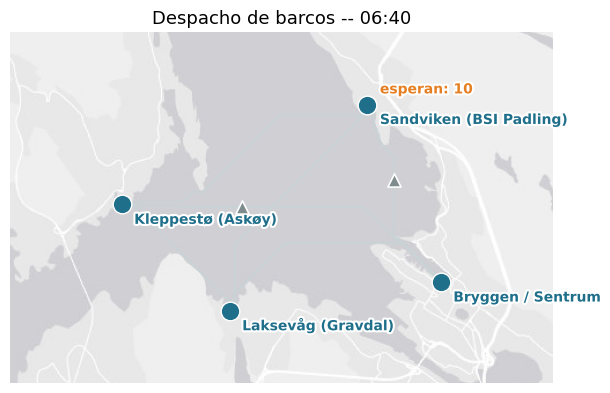


=== BASE, semilla 1001, minuto 400 (inicio+40) ===
=== Minuto 400 ===

Barcos:
  barco_0: B->L (7 min), ocupación=0
  barco_1: S->B (3 min), ocupación=10

Colas (pares con gente esperando):
  L->K: 8 personas, la más antigua lleva 17.3 min

Recompensa del paso: -5.357
  incomodidad = 5.351
  movimiento  = 0.006


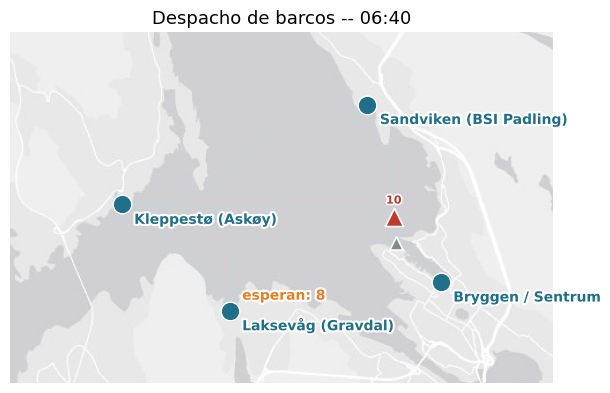


=== AGENTE, semilla 1001, minuto 460 (inicio+100) ===
=== Minuto 460 ===

Barcos:
  barco_0: L->S (3 min), ocupación=0
  barco_1: S->K (6 min), ocupación=0

Colas (pares con gente esperando):
  (ninguna)

Recompensa del paso: -0.006
  incomodidad = 0.000
  movimiento  = 0.006


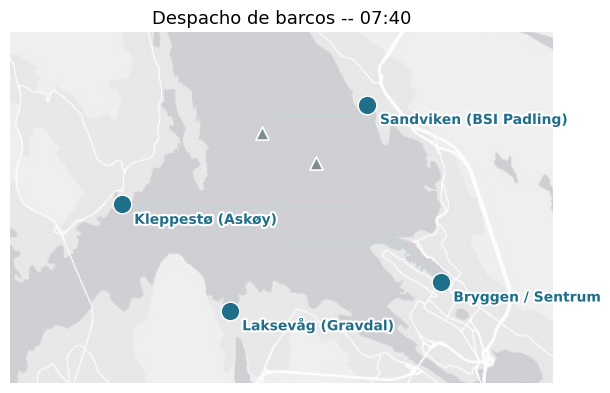


=== BASE, semilla 1001, minuto 460 (inicio+100) ===
=== Minuto 460 ===

Barcos:
  barco_0: libre, ocupación=0, decidió: esperar
  barco_1: libre, ocupación=0, decidió: esperar

Colas (pares con gente esperando):
  (ninguna)

Recompensa del paso: 0.000
  incomodidad = 0.000
  movimiento  = 0.000


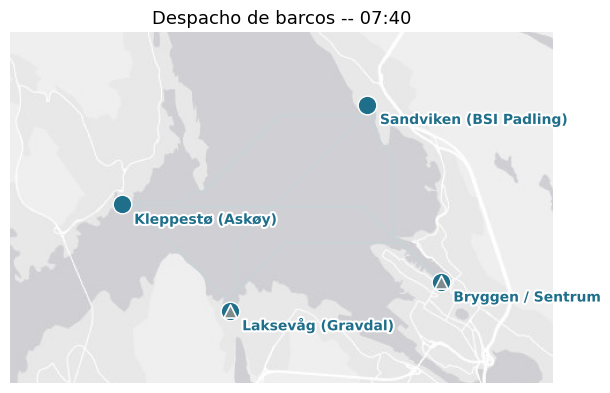


=== Reproductor: AGENTE, semilla 1001 ===



=== Reproductor: BASE, semilla 1001 ===



Semilla 1001 -- conservacion agente: True, base: True
Agente: 85.2% atendidas, espera media 11.8 min
Base:   91.9% atendidas, espera media 9.4 min

Percentiles, semilla 1001:


,metrica,percentil,agente_ppo,politica_base,diferencia
0,espera_min,p50,11.32,8.54,2.78
1,espera_min,p90,26.37,20.27,6.10
2,espera_min,p95,28.27,25.34,2.93
3,espera_min,max,28.27,25.34,2.93
4,viaje_min,p50,10.00,8.00,2.00
5,viaje_min,p90,12.00,12.00,0.00
6,viaje_min,p95,12.00,12.00,0.00
7,viaje_min,max,12.00,12.00,0.00
8,sistema_min,p50,20.07,16.54,3.53
9,sistema_min,p90,36.27,28.27,8.00



=== AGENTE, semilla 1001 -- perfil de espera ===


...

=== BASE, semilla 1001 -- ocupacion de flota ===


=== AGENTE, semilla 1001 -- desglose de recompensa ===


=== BASE, semilla 1001 -- desglose de recompensa ===


=== AGENTE, semilla 1001 -- backlog por par ===


=== BASE, semilla 1001 -- backlog por par ===


In [13]:
env_agente_1001, env_base_1001, reporte_agente_1001, reporte_base_1001 = mostrar_detalle_semilla(1001)


### Semilla 1004


SEMILLA 1004
Agente: 198/216 atendidas
Base:   182/216 atendidas


Guardado: C:\Users\hfons\Andes\OneDrive - Universidad de los Andes\NHH\NHH-Schedule-Free-Autonomous-Boats-in-Bergen\comparacion\output\animacion_agente_semilla1004.gif


Guardado: C:\Users\hfons\Andes\OneDrive - Universidad de los Andes\NHH\NHH-Schedule-Free-Autonomous-Boats-in-Bergen\comparacion\output\animacion_base_semilla1004.gif

=== AGENTE, semilla 1004, minuto 400 (inicio+40) ===
=== Minuto 400 ===

Barcos:
  barco_0: K->B (8 min), ocupación=9
  barco_1: B->S (3 min), ocupación=0

Colas (pares con gente esperando):
  K->S: 7 personas, la más antigua lleva 5.7 min

Recompensa del paso: -0.006
  incomodidad = 0.000
  movimiento  = 0.006


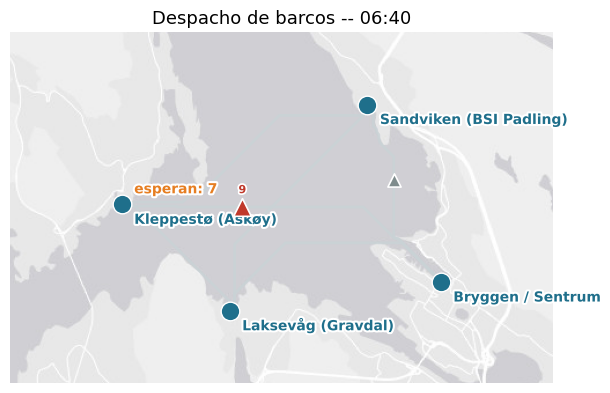


=== BASE, semilla 1004, minuto 400 (inicio+40) ===
=== Minuto 400 ===

Barcos:
  barco_0: K->B (2 min), ocupación=7
  barco_1: K->B (6 min), ocupación=9

Colas (pares con gente esperando):
  K->S: 7 personas, la más antigua lleva 5.7 min

Recompensa del paso: -2.888
  incomodidad = 2.882
  movimiento  = 0.006


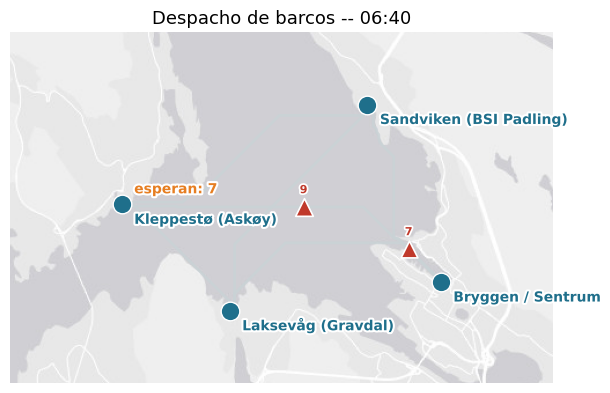


=== AGENTE, semilla 1004, minuto 460 (inicio+100) ===
=== Minuto 460 ===

Barcos:
  barco_0: libre, ocupación=0, decidió: bryggen
  barco_1: K->B (10 min), ocupación=17

Colas (pares con gente esperando):
  L->B: 32 personas, la más antigua lleva 27.7 min
  B->S: 8 personas, la más antigua lleva 22.3 min
  S->B: 8 personas, la más antigua lleva 10.9 min

Recompensa del paso: -20.443
  incomodidad = 20.440
  movimiento  = 0.003


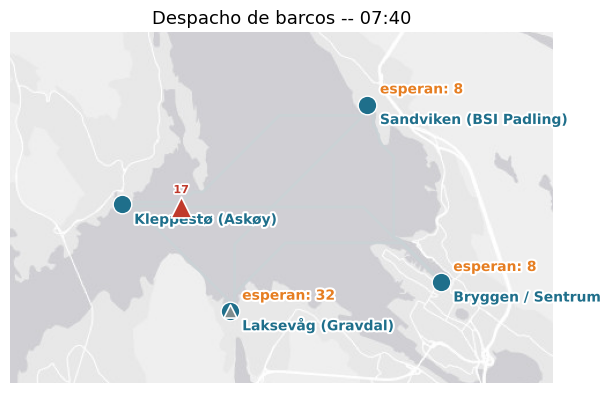


=== BASE, semilla 1004, minuto 460 (inicio+100) ===
=== Minuto 460 ===

Barcos:
  barco_0: libre, ocupación=0, decidió: kleppesto
  barco_1: B->K (10 min), ocupación=0

Colas (pares con gente esperando):
  K->B: 33 personas, la más antigua lleva 37.9 min
  L->B: 32 personas, la más antigua lleva 27.7 min

Recompensa del paso: -46.167
  incomodidad = 46.164
  movimiento  = 0.003


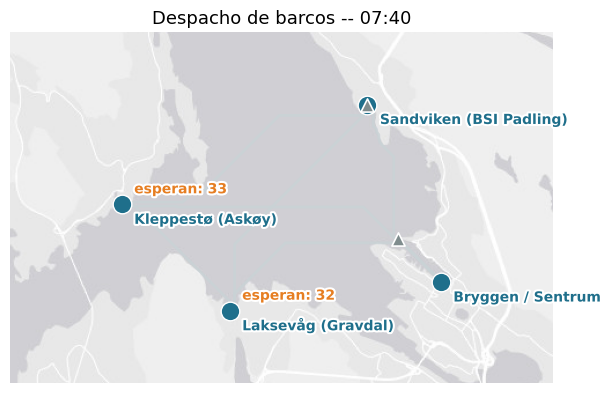


=== Reproductor: AGENTE, semilla 1004 ===



=== Reproductor: BASE, semilla 1004 ===



Semilla 1004 -- conservacion agente: True, base: True
Agente: 91.7% atendidas, espera media 18.2 min
Base:   84.3% atendidas, espera media 27.7 min

Percentiles, semilla 1004:


,metrica,percentil,agente_ppo,politica_base,diferencia
0,espera_min,p50,14.34,23.46,-9.12
1,espera_min,p90,33.74,52.78,-19.04
2,espera_min,p95,37.33,59.22,-21.89
3,espera_min,max,54.77,59.74,-4.97
4,viaje_min,p50,12.00,10.00,2.00
5,viaje_min,p90,12.00,12.00,0.00
6,viaje_min,p95,12.00,12.00,0.00
7,viaje_min,max,12.00,12.00,0.00
8,sistema_min,p50,26.34,35.46,-9.12
9,sistema_min,p90,43.74,64.78,-21.04



=== AGENTE, semilla 1004 -- perfil de espera ===


...

=== BASE, semilla 1004 -- ocupacion de flota ===


=== AGENTE, semilla 1004 -- desglose de recompensa ===


=== BASE, semilla 1004 -- desglose de recompensa ===


=== AGENTE, semilla 1004 -- backlog por par ===


=== BASE, semilla 1004 -- backlog por par ===


In [14]:
env_agente_1004, env_base_1004, reporte_agente_1004, reporte_base_1004 = mostrar_detalle_semilla(1004)
